In [1]:
import os
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

In [11]:
DATA_PATH = "../../data/output_data/"
FIGURES_PATH = "../../data/figures/"
dataset = "high_grade_glioma"
rd=1
# Tools: BAMixChecker, CrossCheckFingerprints, HYSYS, NGSCheckmate, Vireo

In [24]:
def all_samples_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize ALL samples against ALL samples
    extreme_point = max(
        abs(matrix_df.min().min()), abs(matrix_df.max().max())
    )

    fig, ax = plt.subplots(figsize=(10, 10))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(matrix_df, cmap=cmap)

    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=45, ha="left", fontdict={"fontsize": 10})
    ax.set_yticklabels(matrix_df.index, fontdict={"fontsize": 10})
    ax.xaxis.set_label_position("top")
    ax.set_title(f"{tool} Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_rd{rd}_all_samples_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_rd{rd}_all_samples_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

In [64]:
def bulk_vs_singlecell_matrix_viz(matrix_df, tool, dataset, save_fig=False):

    # Visualize bulk against single-cell samples
    sub_matrix = matrix_df[
        [col for col in matrix_df.columns if "single-cell" in col]
    ]
    sub_matrix = sub_matrix.loc[
        [idx for idx in sub_matrix.index if "bulk" in idx]
    ]

    extreme_point = max(
        abs(sub_matrix.min().min()), abs(sub_matrix.max().max())
    )

    fig, ax = plt.subplots(figsize=(8, 8))
    if tool == "CrosscheckFingerprints":
        cmap = plt.get_cmap("RdBu")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap, vmin= -extreme_point, vmax= extreme_point)
    else:
        cmap = plt.get_cmap("Oranges")
        cmap.set_bad(color="lightgrey")
        cax = ax.matshow(sub_matrix, cmap=cmap)

    ax.set_xticks(np.arange(len(sub_matrix.columns)))
    ax.set_yticks(np.arange(len(sub_matrix.index)))
    ax.set_xticklabels(sub_matrix.columns, rotation=45, ha="left")
    ax.set_yticklabels(sub_matrix.index)
    ax.xaxis.set_label_position("top")
    ax.set_xlabel("Single-cell samples")
    ax.set_ylabel("Bulk samples")
    ax.set_title(f"{tool} Bulk vs Single-cell Similarity Matrix", pad=20)

    fig.colorbar(cax, fraction=0.046, pad=0.04, shrink=0.5)

    if save_fig:
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_rd{rd}_bulk_vs_singlecell_similarity_matrix.png",
            ),
            bbox_inches="tight",
            dpi=300,
        )
        fig.savefig(
            os.path.join(
                FIGURES_PATH,
                f"{dataset}_{tool}_rd{rd}_bulk_vs_singlecell_similarity_matrix.pdf",
            ),
            bbox_inches="tight",
            dpi=300,
        )

    return

# Vireo

In [14]:
vireo_matrix = pd.read_csv(DATA_PATH + f"vireo/{dataset}/similarity_matrix.csv", index_col=0)

In [15]:
vireo_matrix.columns = [re.sub(r"[a-zA-Z0-9]{32}_", "", col.replace(".bam", "").replace("ds.", "")) for col in vireo_matrix.columns]
vireo_matrix.index = pd.Index([re.sub(r"[a-zA-Z0-9]{32}_", "", idx.replace(".bam", "").replace("ds.", "")) for idx in vireo_matrix.index])

In [16]:
# Order rows and columns
ordered_columns = sorted(vireo_matrix.columns)
ordered_index = sorted(vireo_matrix.index)
vireo_matrix = vireo_matrix.loc[ordered_index, ordered_columns]

In [17]:
vireo_matrix.head()

,GSM7305261_single-cell,GSM7305262_single-cell,GSM7305263_single-cell,GSM7305264_single-cell,GSM7305265_single-cell,GSM7305266_single-cell,GSM7305267_single-cell,GSM7305268_single-cell,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,0.181327,0.121166,0.180962,0.176028,0.136027,0.212157,0.118295,0.120870,0.140968,0.118805,0.121881,0.131588,0.124493,0.119837,0.182358,0.194635,0.184343,0.165484
GSM7305243_bulk,0.178128,0.124255,0.182119,0.178407,0.138566,0.213208,0.121709,0.123964,0.143154,0.121950,0.125186,0.134097,0.127490,0.123103,0.183858,0.196477,0.185268,0.168089
GSM7305244_bulk,0.207529,0.149614,0.206991,0.204354,0.165502,0.236410,0.148700,0.151607,0.168448,0.149336,0.152057,0.160137,0.154137,0.150056,0.209667,0.220342,0.210584,0.194430
GSM7305245_bulk,0.224143,0.170692,0.217945,0.221576,0.183295,0.252634,0.168587,0.170834,0.187233,0.168978,0.172004,0.179364,0.173622,0.170002,0.226910,0.238441,0.226486,0.213443
GSM7305246_bulk,0.197075,0.141516,0.196532,0.190638,0.153417,0.225193,0.139062,0.140737,0.158513,0.139221,0.142478,0.150123,0.144516,0.140483,0.198938,0.209471,0.199702,0.183502


In [18]:
vireo_matrix.shape

(18, 18)

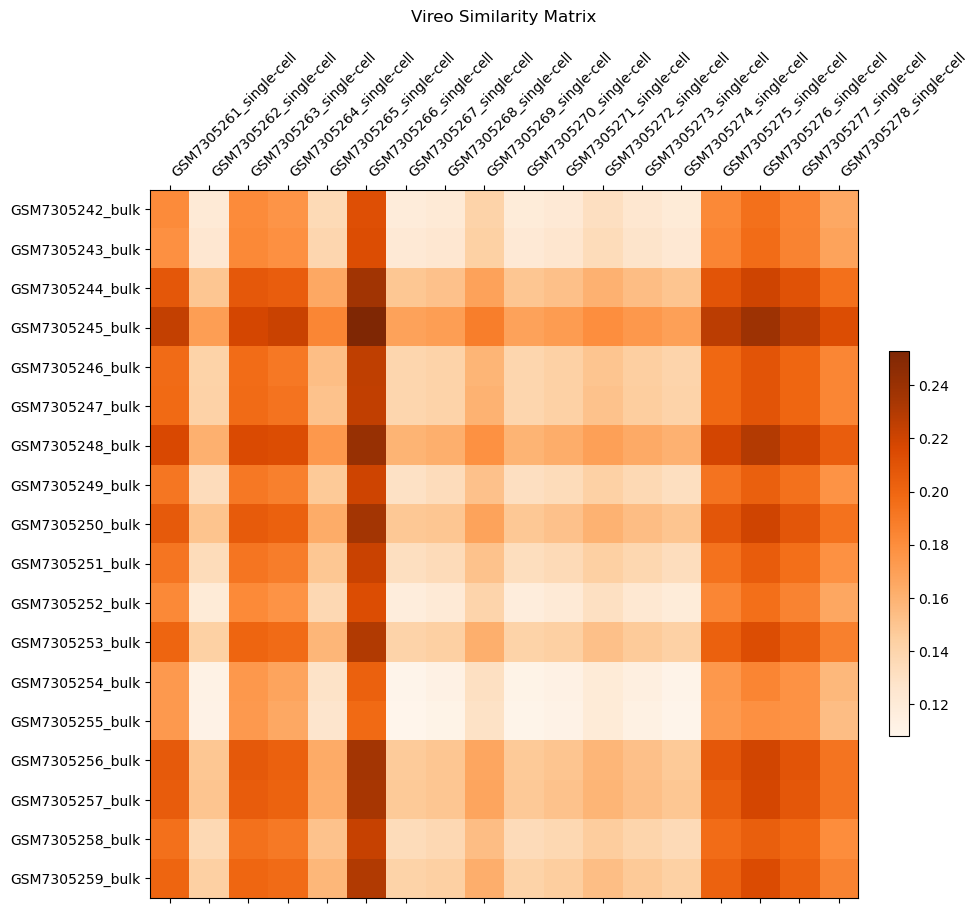

In [25]:
all_samples_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=True)

In [73]:
# bulk_vs_singlecell_matrix_viz(vireo_matrix, tool="Vireo", dataset=dataset, save_fig=False)

In [26]:
vireo_matches = pd.read_csv(DATA_PATH + f"vireo/{dataset}/matched_samples.csv", index_col=0).reset_index()

In [27]:
for col in vireo_matches.columns:
    vireo_matches[col] = [re.sub(r"[a-zA-Z0-9]{32}_", "", sample.replace(".bam", "").replace("ds.", "")) for sample in vireo_matches[col]]

vireo_matches = vireo_matches.sort_values(by=["sample_id_0"]).reset_index(drop=True)

In [28]:
vireo_matches

,sample_id_0,sample_id_1
0,GSM7305261_single-cell,GSM7305243_bulk
1,GSM7305262_single-cell,GSM7305244_bulk
2,GSM7305263_single-cell,GSM7305245_bulk
3,GSM7305264_single-cell,GSM7305246_bulk
4,GSM7305265_single-cell,GSM7305247_bulk
5,GSM7305266_single-cell,GSM7305248_bulk
6,GSM7305267_single-cell,GSM7305249_bulk
7,GSM7305268_single-cell,GSM7305242_bulk
8,GSM7305269_single-cell,GSM7305251_bulk
9,GSM7305270_single-cell,GSM7305252_bulk


# NGSCheckmate

In [329]:
ngscheckmate_df = pd.read_csv(DATA_PATH + f"ngscheckmate/{dataset}/output_all.txt", sep="\t", index_col=0, header=None)

In [330]:
ngscheckmate_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace("ds.", "").replace("_filtered_variants.vcf", "").replace("_bulk_chunk_ribo.bam", ""))
    for x in list(set(ngscheckmate_df.index) | set(ngscheckmate_df[2]))
}
ngscheckmate_df.index = ngscheckmate_df.index.map(ngscheckmate_dict)
ngscheckmate_df[2] = ngscheckmate_df[2].map(ngscheckmate_dict)
ngscheckmate_df.columns = ["Matched", "Sample", "Binary", "Correlation"]

In [331]:
ngscheckmate_df.head()

,Matched,Sample,Binary,Correlation
0,,,,
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2018_bulk_diss_polyA,1.0,583.83
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2023_bulk_diss_polyA,1.0,574.69
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2023_bulk_chunk_ribo,1.0,586.09
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2094_bulk_diss_polyA,1.0,569.97
HGSOC-2018_bulk_chunk_ribo,matched,HGSOC-2094_bulk_chunk_ribo,1.0,574.82


In [332]:
def long_df_to_matrix_ngscheckmate(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Correlation"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]/100
                matrix.at[x, y] = corr_value.values[0]/100

    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(
        key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1]
    )
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [333]:
ngscheckmate_matrix = long_df_to_matrix_ngscheckmate(ngscheckmate_df)

In [334]:
ngscheckmate_matrix.head()

,HGSOC-2018_bulk_chunk_ribo,HGSOC-2023_bulk_chunk_ribo,HGSOC-2094_bulk_chunk_ribo,HGSOC-2126_bulk_chunk_ribo,HGSOC-2129_bulk_chunk_ribo,HGSOC-2186_bulk_chunk_ribo,HGSOC-2202_bulk_chunk_ribo,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_chunk_ribo,...,HGSOC-2408_bulk_diss_polyA,HGSOC-2416_bulk_diss_polyA,HGSOC-2423_bulk_diss_polyA,HGSOC-2455_bulk_diss_polyA,HGSOC-2460_bulk_diss_polyA,HGSOC-2466_bulk_diss_polyA,HGSOC-2477_bulk_diss_polyA,HGSOC-2483_bulk_diss_polyA,HGSOC-2514_bulk_diss_polyA,HGSOC-2526_bulk_diss_polyA
HGSOC-2018_bulk_chunk_ribo,NaN,5.8609,5.7482,5.8609,5.4847,5.8609,5.8609,5.6679,5.1009,5.4775,...,5.5961,4.8619,5.6325,5.7808,5.5498,5.6222,5.5443,5.4504,5.2125,5.5722
HGSOC-2023_bulk_chunk_ribo,5.8609,NaN,5.7482,5.8776,5.4847,5.8836,5.8679,5.6679,5.1009,5.4775,...,5.5961,4.8619,5.6325,5.7808,5.5498,5.6222,5.5443,5.4504,5.2125,5.5722
HGSOC-2094_bulk_chunk_ribo,5.7482,5.7482,NaN,5.7482,5.4847,5.7482,5.7482,5.6679,5.1009,5.4775,...,5.5961,4.8619,5.6325,5.7482,5.5498,5.6222,5.5443,5.4504,5.2125,5.5722
HGSOC-2126_bulk_chunk_ribo,5.8609,5.8776,5.7482,NaN,5.4847,5.8776,5.8679,5.6679,5.1009,5.4775,...,5.5961,4.8619,5.6325,5.7808,5.5498,5.6222,5.5443,5.4504,5.2125,5.5722
HGSOC-2129_bulk_chunk_ribo,5.4847,5.4847,5.4847,5.4847,NaN,5.4847,5.4847,5.4847,5.1009,5.4775,...,5.4847,4.8619,5.4847,5.4847,5.4847,5.4847,5.4847,5.4504,5.2125,5.4847


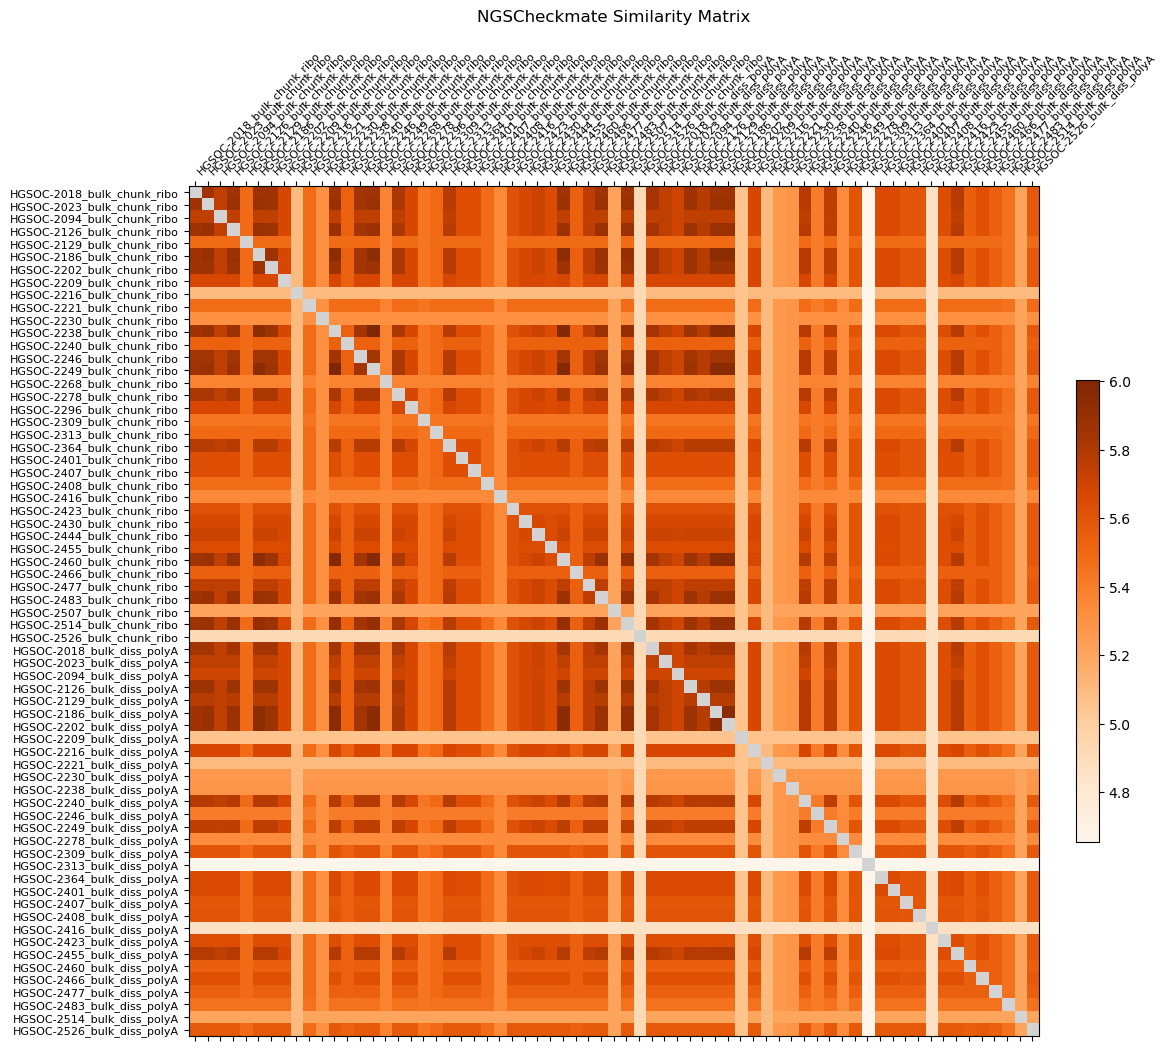

In [335]:
all_samples_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

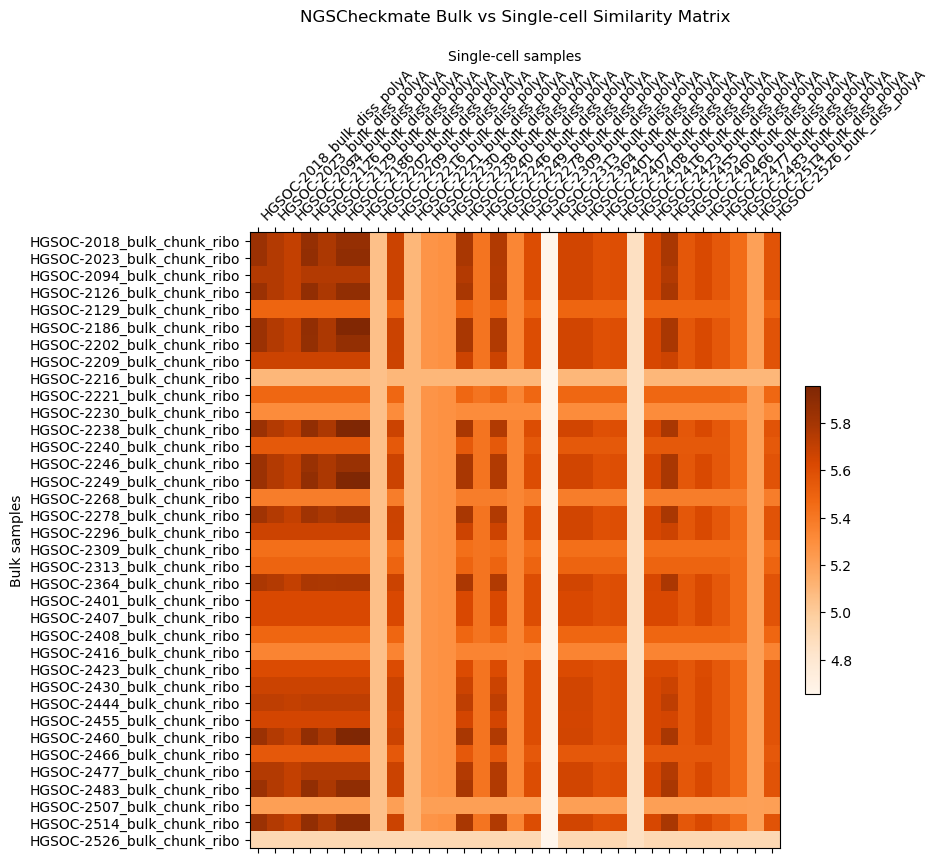

In [336]:
bulk_vs_singlecell_matrix_viz(ngscheckmate_matrix, tool="NGSCheckmate", dataset=dataset, save_fig=True)

# HYSYS

In [29]:
hysys_df = pd.read_csv(DATA_PATH + f"hysys/{dataset}/concordance_output.txt", sep="\t", index_col=0, header=None)

In [30]:
hysys_dict = {
    x: 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace(f"{dataset}/", "").replace("_filtered_variants.snps", "").replace("ds.", ""))
    # x.replace("_filtered_variants.snps", "").replace(f"{dataset}/", "")
    for x in list(set(hysys_df.index) | set(hysys_df[1]))
}
hysys_df.index = hysys_df.index.map(hysys_dict)
hysys_df[1] = hysys_df[1].map(hysys_dict)
hysys_df.columns = ["Sample", "Concordance", "Size"]

In [31]:
hysys_df.head()

,Sample,Concordance,Size
0,,,
GSM7305242_bulk,GSM7305260_single-cell,0.029,328177
GSM7305242_bulk,GSM7305261_single-cell,0.025,254630
GSM7305242_bulk,GSM7305262_single-cell,0.011,171372
GSM7305242_bulk,GSM7305263_single-cell,0.024,256625
GSM7305242_bulk,GSM7305264_single-cell,0.017,262254


In [32]:
def long_df_to_matrix_hysys(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance"]
            if not corr_value.empty:
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [33]:
hysys_matrix = long_df_to_matrix_hysys(hysys_df)

In [34]:
hysys_matrix.head()

,GSM7305260_single-cell,GSM7305261_single-cell,GSM7305262_single-cell,GSM7305263_single-cell,GSM7305264_single-cell,GSM7305265_single-cell,GSM7305266_single-cell,GSM7305267_single-cell,GSM7305268_single-cell,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,0.029,0.025,0.011,0.024,0.017,0.016,0.018,0.011,0.009,0.014,0.013,0.009,0.014,0.009,0.009,0.019,0.014,0.026,0.015
GSM7305243_bulk,0.028,0.040,0.013,0.029,0.018,0.020,0.019,0.013,0.011,0.016,0.016,0.011,0.016,0.011,0.011,0.023,0.015,0.030,0.016
GSM7305244_bulk,0.028,0.028,0.016,0.029,0.018,0.018,0.021,0.011,0.009,0.016,0.013,0.010,0.015,0.011,0.010,0.020,0.016,0.029,0.015
GSM7305245_bulk,0.034,0.030,0.012,0.044,0.020,0.020,0.023,0.011,0.010,0.016,0.013,0.009,0.014,0.011,0.009,0.022,0.016,0.031,0.015
GSM7305246_bulk,0.030,0.029,0.011,0.029,0.023,0.019,0.021,0.011,0.010,0.015,0.013,0.010,0.015,0.010,0.010,0.022,0.016,0.030,0.016


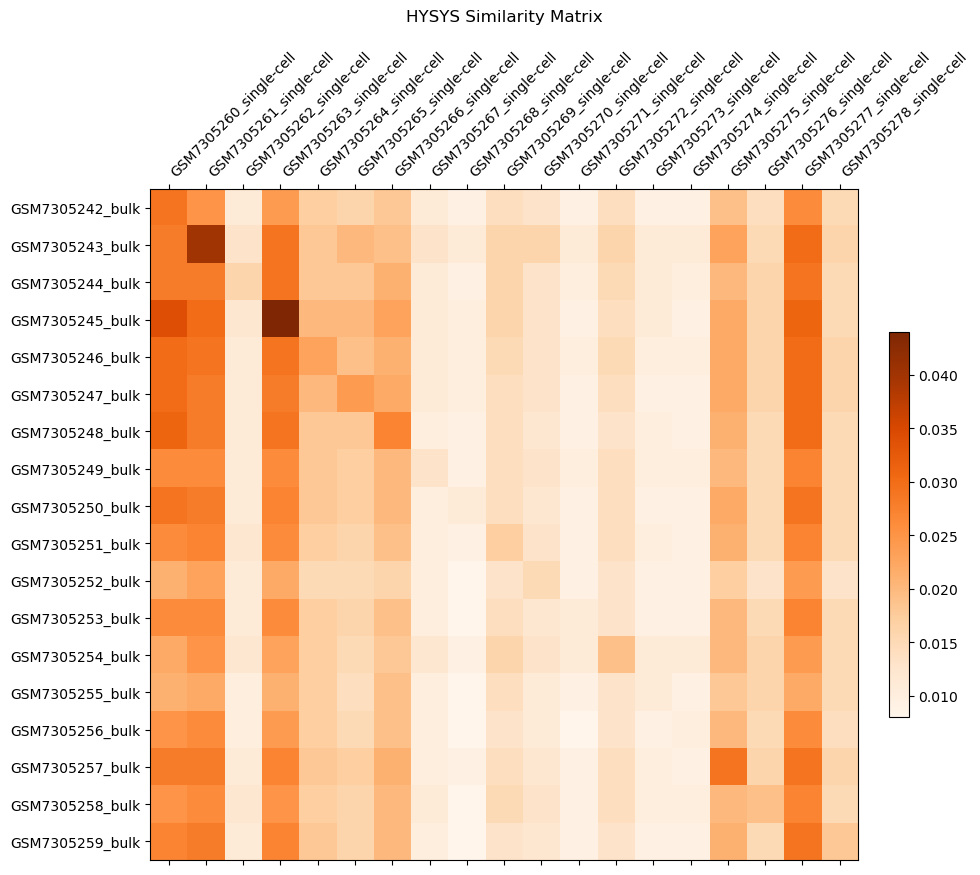

In [35]:
all_samples_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

In [103]:
# bulk_vs_singlecell_matrix_viz(hysys_matrix, tool="HYSYS", dataset=dataset, save_fig=True)

# CrossCheckFingerprints

In [53]:
fingerprints_df = pd.read_csv(DATA_PATH + f"fingerprints/{dataset}/crosscheck_metrics.txt", sep="\t", header=5)
fingerprints_df = fingerprints_df[["LEFT_SAMPLE", "RIGHT_SAMPLE", "LOD_SCORE", "RESULT"]]

In [54]:
fingerprints_dict = {
    x: 
    # x.replace(".bam", "")
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace(".bam", "").replace("ds.", ""))
    
    for x in list(set(fingerprints_df["LEFT_SAMPLE"]) | set(fingerprints_df["RIGHT_SAMPLE"]))
}
fingerprints_df["LEFT_SAMPLE"] = fingerprints_df["LEFT_SAMPLE"].map(fingerprints_dict)
fingerprints_df["RIGHT_SAMPLE"] = fingerprints_df["RIGHT_SAMPLE"].map(fingerprints_dict)

In [55]:
fingerprints_df.head()

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,GSM7305273_single-cell,GSM7305273_single-cell,22.762291,EXPECTED_MATCH
1,GSM7305273_single-cell,GSM7305263_single-cell,-6.929468,EXPECTED_MISMATCH
2,GSM7305273_single-cell,GSM7305270_single-cell,-0.309950,EXPECTED_MISMATCH
3,GSM7305273_single-cell,GSM7305276_single-cell,-2.522338,EXPECTED_MISMATCH
4,GSM7305273_single-cell,GSM7305249_bulk,-7.323864,EXPECTED_MISMATCH


In [56]:
def long_df_to_matrix_fingerprints(df):
    matrix = pd.DataFrame()

    for x in df["LEFT_SAMPLE"].unique():
        for y in df["RIGHT_SAMPLE"].unique():
            corr_value = df.loc[(df["LEFT_SAMPLE"] == x) & (df["RIGHT_SAMPLE"] == y), "LOD_SCORE"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]

    # Order rows and columns by bulk modality and sample ID
    matrix = matrix.sort_index(key=lambda x: x.str.split('_').str[0]).sort_index(key=lambda x: x.str.split('_', n=1).str[1])
    matrix = matrix.reindex(
        sorted(
            sorted(
                matrix.columns,
                key=lambda x: x.split('_', 1)[0]
            ),
            key=lambda x: x.split('_', 1)[1]
        )
    )
    matrix = matrix[matrix.index]

    return matrix

In [57]:
fingerprints_matrix = long_df_to_matrix_fingerprints(fingerprints_df)

In [58]:
fingerprints_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,195.046881,-197.311498,-67.207515,-215.330683,-132.348288,-38.393540,-79.420017,-188.220220,-49.494510,-138.579285,...,-4.082889,-2.417379,-7.965278,-17.501687,-3.806610,-0.836386,-25.125814,-19.779625,-6.916506,-4.497357
GSM7305243_bulk,-197.311498,284.362607,-203.381473,-333.768906,-251.150704,-207.659500,-244.225570,-302.169428,-211.287754,-256.580570,...,-27.098784,-14.285891,-9.339075,-20.213988,-8.792842,-11.384365,-57.751858,-63.346890,-43.015559,-42.049847
GSM7305244_bulk,-67.207515,-203.381473,280.094677,-310.286141,-197.693543,-65.253798,-58.073310,-200.260725,-98.305692,-219.411146,...,-4.802929,-2.759796,-14.179272,-24.477605,-5.262210,-5.278815,-30.390619,-19.382687,-11.621268,-6.482717
GSM7305245_bulk,-215.330683,-333.768906,-310.286141,456.311553,-308.719196,-218.099829,-330.036737,-327.033343,-312.611310,-340.942520,...,-31.326280,-4.765076,-10.974567,-8.647423,-9.907846,-8.527107,-55.696725,-84.152308,-60.211243,-44.324598
GSM7305246_bulk,-132.348288,-251.150704,-197.693543,-308.719196,321.265079,-168.817257,-197.611817,-247.167645,-242.015388,-243.834278,...,-17.962981,-13.834515,-14.274299,-25.110556,-12.048995,-3.595329,-69.954455,-110.863832,-56.214713,-65.610279


In [59]:
# all_samples_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

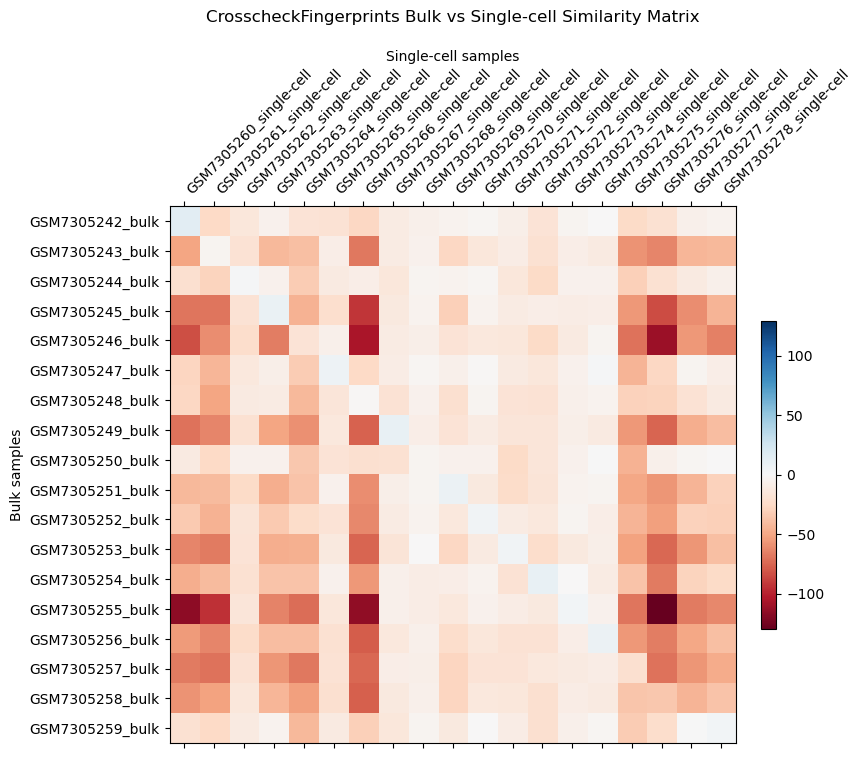

In [65]:
bulk_vs_singlecell_matrix_viz(fingerprints_matrix, tool="CrosscheckFingerprints", dataset=dataset, save_fig=True)

In [352]:
fingerprints_df["RESULT"].value_counts()

RESULT
EXPECTED_MISMATCH    4360
EXPECTED_MATCH         67
UNEXPECTED_MATCH       62
Name: count, dtype: int64

In [353]:
# Confirmed that the expected matches are simply the samples matching themselves
fingerprint_exp_matches = fingerprints_df[fingerprints_df["RESULT"]=="EXPECTED_MATCH"]
fingerprint_exp_matches[fingerprint_exp_matches["LEFT_SAMPLE"] != fingerprint_exp_matches["RIGHT_SAMPLE"]]

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT


In [354]:
fingerprints_matches = fingerprints_df[fingerprints_df["RESULT"]=="UNEXPECTED_MATCH"]

In [355]:
# Out of 80 unexpected matches
# There should be really only 40 pairs since it's symmetric
#
# 5/40 are polyA vs polyA (and they all involve sample 2507)
# 0 are ribo vs ribo
# 35/40 are polyA vs ribo
fingerprints_matches[
    ~(fingerprints_matches["LEFT_SAMPLE"].str.contains("polyA") & fingerprints_matches["RIGHT_SAMPLE"].str.contains("polyA"))
].sort_values(
    by=["LEFT_SAMPLE", "RIGHT_SAMPLE"]
).drop_duplicates(
    "LOD_SCORE"
).reset_index(
    drop=True
)

,LEFT_SAMPLE,RIGHT_SAMPLE,LOD_SCORE,RESULT
0,HGSOC-2018_bulk_chunk_ribo,HGSOC-2018_bulk_diss_polyA,197.938691,UNEXPECTED_MATCH
1,HGSOC-2023_bulk_chunk_ribo,HGSOC-2023_bulk_diss_polyA,186.372326,UNEXPECTED_MATCH
2,HGSOC-2094_bulk_chunk_ribo,HGSOC-2094_bulk_diss_polyA,204.709169,UNEXPECTED_MATCH
3,HGSOC-2126_bulk_chunk_ribo,HGSOC-2126_bulk_diss_polyA,221.965748,UNEXPECTED_MATCH
4,HGSOC-2129_bulk_chunk_ribo,HGSOC-2129_bulk_diss_polyA,182.191976,UNEXPECTED_MATCH
5,HGSOC-2186_bulk_chunk_ribo,HGSOC-2186_bulk_diss_polyA,205.165566,UNEXPECTED_MATCH
6,HGSOC-2202_bulk_chunk_ribo,HGSOC-2202_bulk_diss_polyA,227.722145,UNEXPECTED_MATCH
7,HGSOC-2209_bulk_chunk_ribo,HGSOC-2216_bulk_diss_polyA,195.143683,UNEXPECTED_MATCH
8,HGSOC-2209_bulk_diss_polyA,HGSOC-2526_bulk_chunk_ribo,193.867424,UNEXPECTED_MATCH
9,HGSOC-2216_bulk_chunk_ribo,HGSOC-2221_bulk_diss_polyA,244.463959,UNEXPECTED_MATCH


# BAMixChecker

In [66]:
bamixchecker_df = pd.read_csv(DATA_PATH + f"bamixchecker/{dataset}/BAMixChecker/Total_result.txt", sep="\t", index_col=0, header=None)
bamixchecker_df.columns = ["Sample", "Concordance Rate", "Conclusion"]

In [67]:
bamixchecker_dict = {
    x: 
    # x.replace("_filtered_rg.bam", "") 
    re.sub(r"[a-zA-Z0-9]{32}_", "", x.replace("_filtered_rg.bam", "").replace(f"{dataset}/", "").replace("_filtered_variants.snps", "").replace("ds.", ""))
    for x in list(set(bamixchecker_df.index) | set(bamixchecker_df["Sample"]))
}
bamixchecker_df.index = bamixchecker_df.index.map(bamixchecker_dict)
bamixchecker_df["Sample"] = bamixchecker_df["Sample"].map(bamixchecker_dict)

In [68]:
bamixchecker_df.head()

,Sample,Concordance Rate,Conclusion
0,,,
GSM7305243_bulk,GSM7305270_single-cell,0.0,Unmatched
GSM7305243_bulk,GSM7305249_bulk,0.0,Unmatched
GSM7305243_bulk,GSM7305248_bulk,0.0,Unmatched
GSM7305243_bulk,GSM7305253_bulk,0.0,Unmatched
GSM7305243_bulk,GSM7305252_bulk,0.0,Unmatched


In [69]:
def long_df_to_matrix_bamixchecker(df):
    matrix = pd.DataFrame()

    for x in list(df.index):
        for y in df["Sample"].values:
            corr_value = df.loc[(df.index == x) & (df["Sample"] == y), "Concordance Rate"]
            if not corr_value.empty:
                matrix.at[y, x] = corr_value.values[0]
                matrix.at[x, y] = corr_value.values[0]

    # Order rows and columns
    matrix = matrix[matrix.columns.sort_values()]
    matrix = matrix.reindex(sorted(matrix.index))

    return matrix

In [70]:
bamixchecker_matrix = long_df_to_matrix_bamixchecker(bamixchecker_df)

In [71]:
bamixchecker_matrix.head()

,GSM7305242_bulk,GSM7305243_bulk,GSM7305244_bulk,GSM7305245_bulk,GSM7305246_bulk,GSM7305247_bulk,GSM7305248_bulk,GSM7305249_bulk,GSM7305250_bulk,GSM7305251_bulk,...,GSM7305269_single-cell,GSM7305270_single-cell,GSM7305271_single-cell,GSM7305272_single-cell,GSM7305273_single-cell,GSM7305274_single-cell,GSM7305275_single-cell,GSM7305276_single-cell,GSM7305277_single-cell,GSM7305278_single-cell
GSM7305242_bulk,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305243_bulk,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305244_bulk,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305245_bulk,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
GSM7305246_bulk,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
# all_samples_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

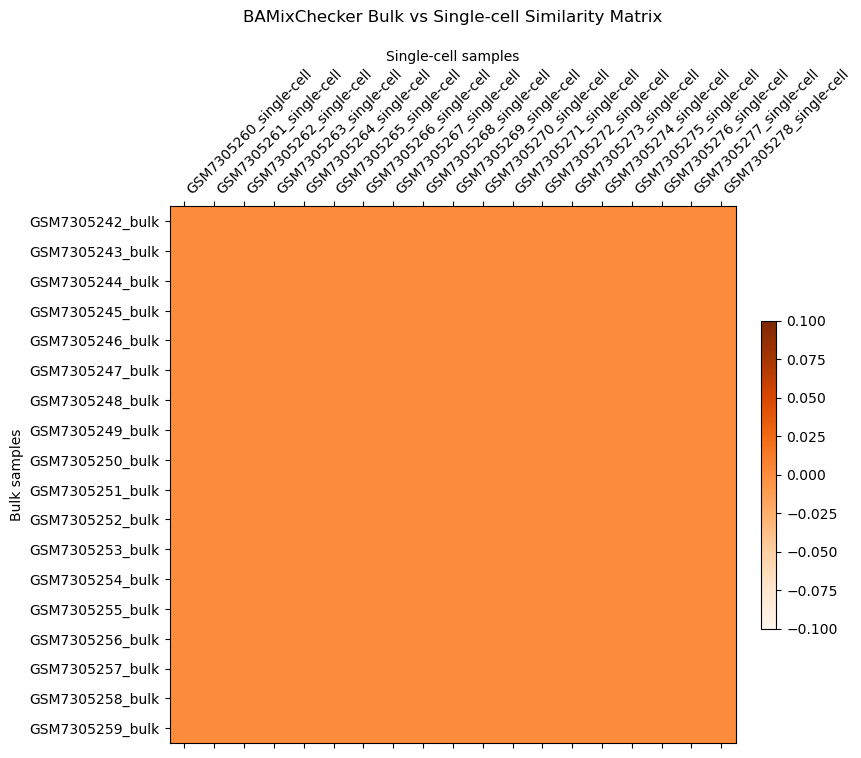

In [73]:
bulk_vs_singlecell_matrix_viz(bamixchecker_matrix, tool="BAMixChecker", dataset=dataset, save_fig=True)

# Tool comparison

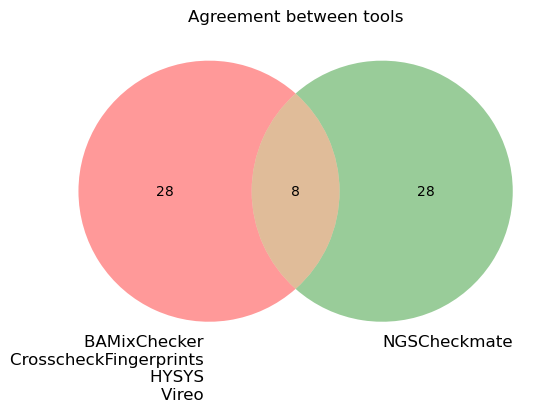

In [ ]:
venn2(subsets=(28, 28, 8), set_labels=('BAMixChecker \nCrosscheckFingerprints \nHYSYS \nVireo ', 'NGSCheckmate'))
plt.title("Agreement between tools")
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.png", bbox_inches="tight", dpi=300)
# plt.savefig(FIGURES_PATH + f"{dataset}_tool_agreement_venn_diagram.pdf", bbox_inches="tight", dpi=300